# 03 — Exploratory Data Analysis

## Objective

Explore sales, customers, products, geography and temporal patterns in the cleaned transaction data.

In [12]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils import get_processed_data_dir

DATA_DIR = get_processed_data_dir()

sales = pd.read_csv(
    DATA_DIR / "online_retail_sales.csv",
    parse_dates=["InvoiceDate"]
)

/var/folders/ns/ms3xw2y52nj8x7n_3w_qw4tm0000gn/T/ipykernel_60371/350488312.py:18: DtypeWarning: Columns (0: Invoice) have mixed types. Specify dtype option on import or set low_memory=False.
  sales = pd.read_csv(


## Revenue Distribution

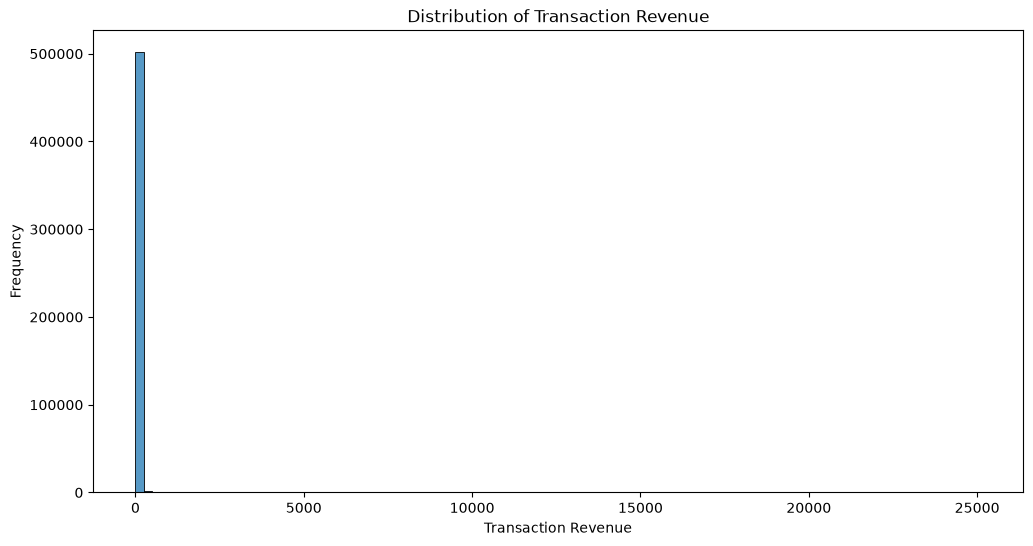

In [13]:
plt.figure(figsize=(12, 6))

sns.histplot(
    sales["TotalPrice"],
    bins=100
)

plt.title(
    "Distribution of Transaction Revenue"
)

plt.xlabel("Transaction Revenue")

plt.ylabel("Frequency")

plt.show()

## Monthly Revenue

In [14]:
monthly_revenue = (
    sales
    .set_index("InvoiceDate")
    .resample("ME")["TotalPrice"]
    .sum()
    .reset_index()
)

monthly_revenue.head()

,InvoiceDate,TotalPrice
0,2009-12-31,822483.950
1,2010-01-31,651155.112
2,2010-02-28,551878.296
3,2010-03-31,830915.261
4,2010-04-30,678875.252


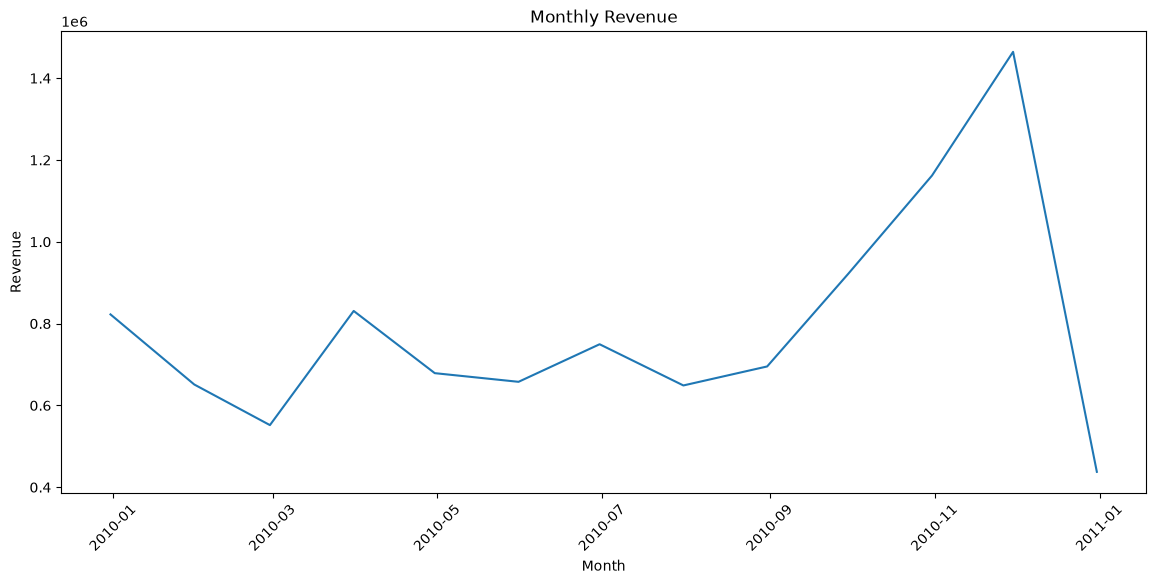

In [15]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly_revenue,
    x="InvoiceDate",
    y="TotalPrice"
)

plt.title("Monthly Revenue")

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

## Day-of-Week Analysis

In [16]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_sales = (
    sales
    .groupby("DayOfWeek")["TotalPrice"]
    .sum()
    .reindex(weekday_order)
)

weekday_sales

DayOfWeek
Monday       1860809.825
Tuesday      2002003.301
Wednesday    1745382.103
Thursday     2097097.802
Friday       1533319.022
Saturday        9803.050
Sunday       1023721.131
Name: TotalPrice, dtype: float64

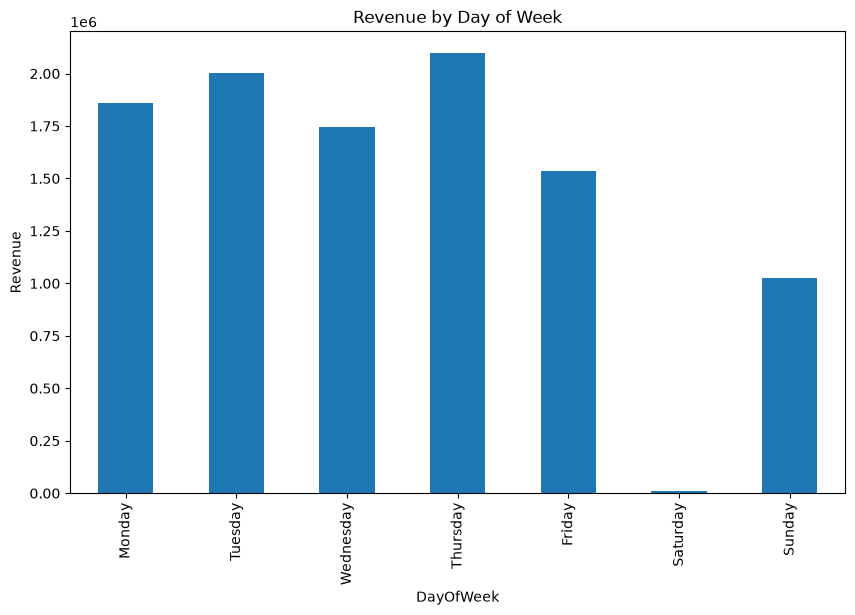

In [17]:
weekday_sales.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Revenue by Day of Week"
)

plt.ylabel("Revenue")

plt.show()

## Hourly Analysis

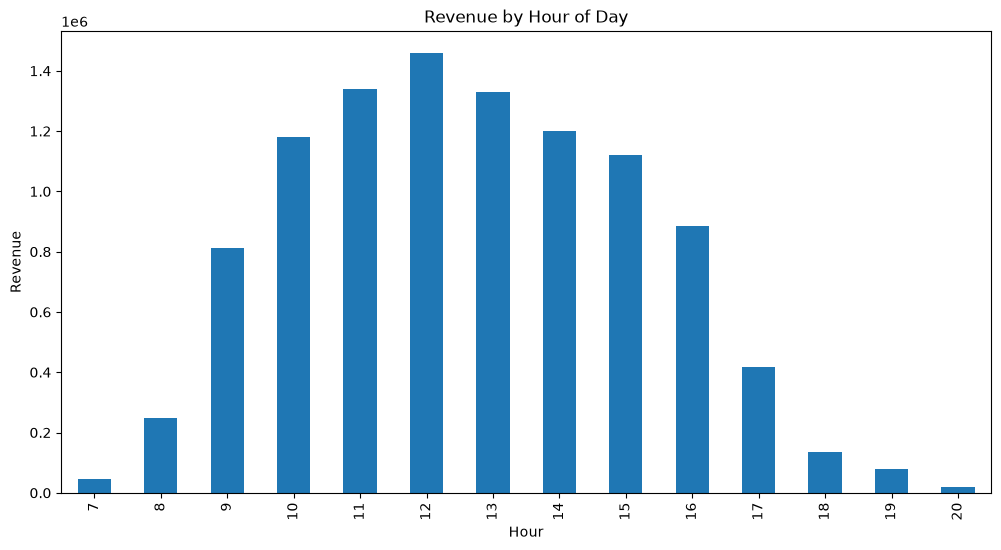

In [18]:
hourly_sales = (
    sales
    .groupby("Hour")["TotalPrice"]
    .sum()
)

hourly_sales.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "Revenue by Hour of Day"
)

plt.ylabel("Revenue")

plt.show()

## Country Analysis

In [19]:
country_sales = (
    sales
    .groupby("Country")
    .agg(
        Revenue=("TotalPrice", "sum"),
        Units=("Quantity", "sum"),
        Orders=("Invoice", "nunique"),
        Customers=("CustomerID", "nunique")
    )
    .sort_values(
        "Revenue",
        ascending=False
    )
)

country_sales.head(15)

,Revenue,Units,Orders,Customers
Country,,,,
United Kingdom,8812685.403,4702281,19292,3969
EIRE,380909.570,193047,348,5
Netherlands,268784.350,183615,135,22
Germany,202025.391,108615,347,67
France,147103.140,163029,241,47
Sweden,53501.990,52555,69,16
Denmark,50906.850,229690,26,9
Spain,47568.650,22841,66,25
Switzerland,43921.390,22255,40,14


## Product Analysis

In [20]:
product_sales = (
    sales
    .groupby(
        ["StockCode", "DescriptionClean"]
    )
    .agg(
        Revenue=("TotalPrice", "sum"),
        Units=("Quantity", "sum"),
        Orders=("Invoice", "nunique"),
        Customers=("CustomerID", "nunique")
    )
    .reset_index()
    .sort_values(
        "Revenue",
        ascending=False
    )
)

product_sales.head(20)

,StockCode,DescriptionClean,Revenue,Units,Orders,Customers
4689,M,MANUAL,262950.93,2765,513,283
1841,22423,REGENCY CAKESTAND 3 TIER,169912.76,13685,2019,818
4087,85123A,WHITE HANGING HEART T-LIGHT HOLDER,158305.72,58386,3281,1141
4688,DOT,DOTCOM POSTAGE,116408.71,730,730,0
3747,84879,ASSORTED COLOUR BIRD ORNAMENT,72890.19,45228,1412,627
1444,22086,PAPER CHAIN KIT 50'S CHRISTMAS,58127.30,17205,957,505
4057,85099B,JUMBO BAG RED RETROSPOT,54368.82,30327,1222,539
2864,47566,PARTY BUNTING,49664.12,10079,1013,391
4691,POST,POSTAGE,49477.54,2310,759,230
3342,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,47954.49,23037,347,177


## Correlation Analysis

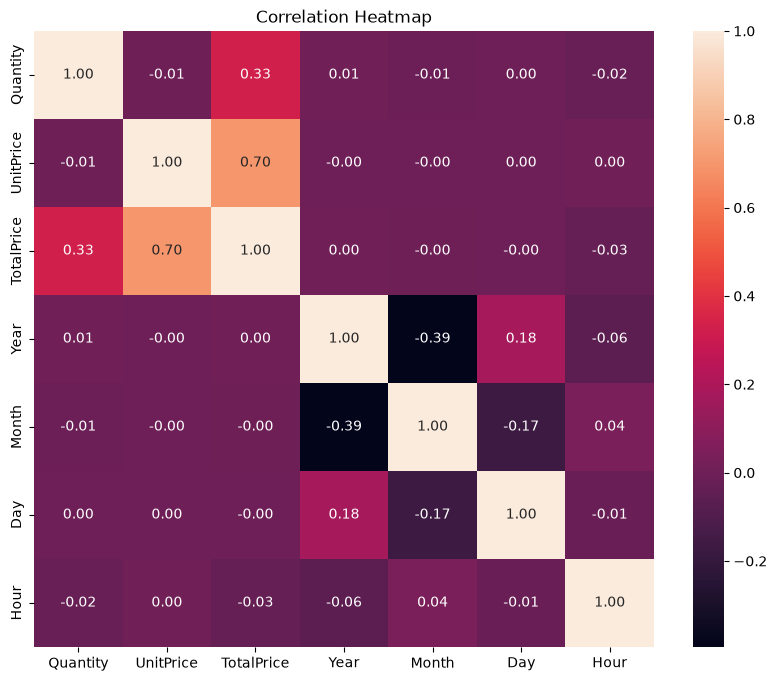

In [21]:
numeric_columns = [
    "Quantity",
    "UnitPrice",
    "TotalPrice",
    "Year",
    "Month",
    "Day",
    "Hour"
]

correlation = (
    sales[numeric_columns]
    .corr()
)

plt.figure(
    figsize=(10, 8)
)

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title(
    "Correlation Heatmap"
)

plt.show()

## Missingness Analysis

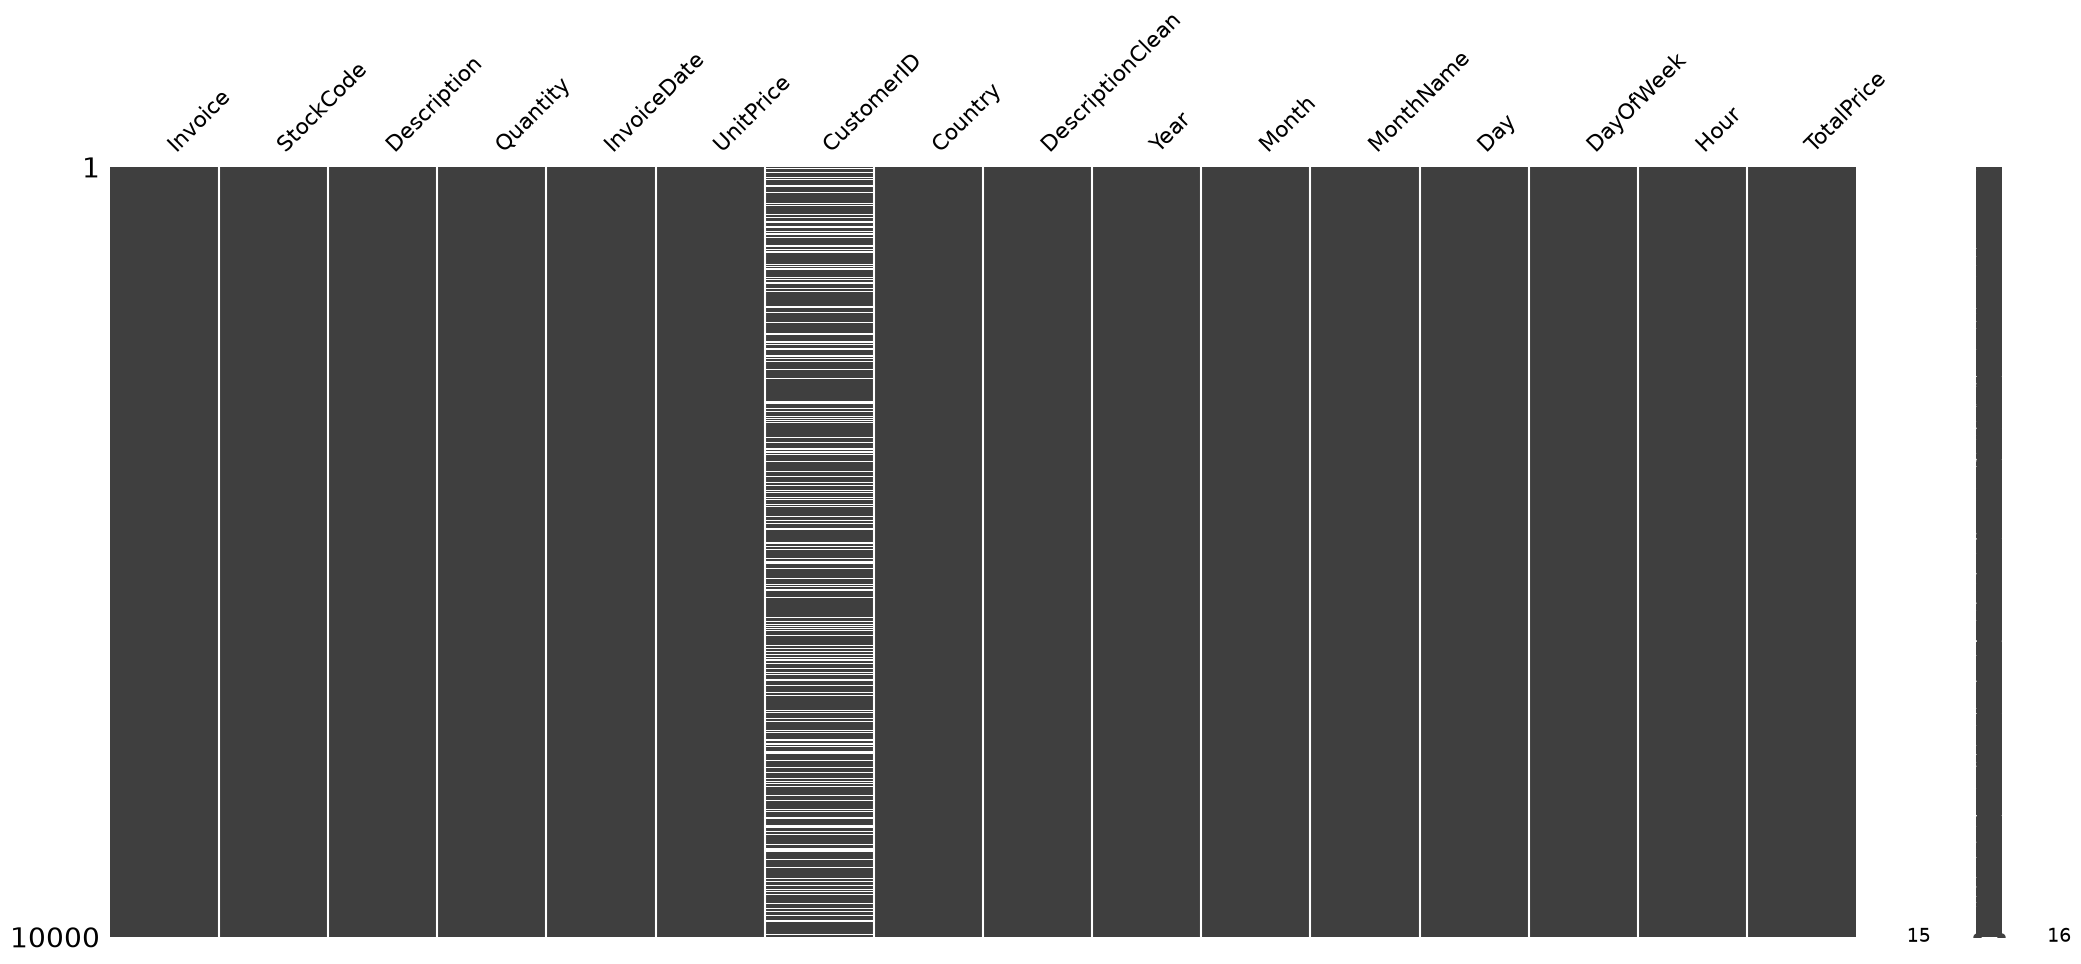

In [22]:
import missingno as msno

msno.matrix(
    sales.sample(
        min(10000, len(sales)),
        random_state=42
    )
)

plt.show()